# Realized Volatility Forecasting with Machine Learning

**Прогнозирование реализованной волатильности акций Apple (AAPL) с помощью ML и эконометрических моделей.**

Цель проекта — построить пайплайн для предсказания будущей реализованной волатильности по историческим OHLCV-данным, используя walk-forward validation без data leakage.

**Стек:** Python, pandas, numpy, scikit-learn, matplotlib, yfinance, arch.


In [24]:
import pandas as pd
import numpy as np
import os
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')


## 1. Загрузка данных

Загружаем исторические OHLCV-данные Apple (AAPL) с Yahoo Finance за 2017–2024 гг. (~8 лет дневных данных).


In [2]:
ticker = "AAPL"
startDate = "2017-01-01"
endDate = "2024-12-31"

data = yf.download(ticker, start=startDate, end=endDate)
data.columns = data.columns.droplevel(1)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
data.dropna(inplace=True)

print(f"Загружено {len(data)} торговых дней")
data.head()


[*********************100%***********************]  1 of 1 completed

Загружено 2011 торговых дней


Price,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,26.665267,26.787310,26.425786,26.745861,115127600
2017-01-04,26.676776,26.828755,26.653749,26.715921,84472400
2017-01-05,26.692893,26.909347,26.667563,26.851780,88774400
2017-01-06,26.890928,27.208702,26.819545,27.151134,127007600
2017-01-09,27.160341,27.501142,27.158040,27.399822,134247600


## 2. Feature Engineering

### 2.1 Логарифмические доходности и реализованная волатильность

В качестве основной метрики реализованной волатильности используется **bipower variation** (BPV) — робастная к скачкам оценка вариации:

$$BPV_t = \frac{\pi}{2} \sum_{j=2}^{w} |r_{t-j+1}| \cdot |r_{t-j}|$$

где $w = 21$ дней (торговый месяц). Годовая реализованная волатильность: $RV_t = \sqrt{BPV_t \cdot 252}$.


In [3]:
windowSize = 21

data['logReturn'] = np.log(data['Close']) - np.log(data['Close'].shift(1))

def computeBpv(returns, window):
    result = np.full(len(returns), np.nan)
    rets = returns.values
    for i in range(window, len(rets)):
        wRets = rets[i - window + 1 : i + 1]
        if np.isnan(wRets).any():
            continue
        absProd = np.abs(wRets[1:]) * np.abs(wRets[:-1])
        bpv = (np.pi / 2) * np.sum(absProd)
        result[i] = bpv
    return result

data['bpv'] = computeBpv(data['logReturn'], windowSize)
data['realizedVol'] = np.sqrt(data['bpv']) * np.sqrt(252)

data[['Close', 'logReturn', 'realizedVol']].dropna().head()


Price,Close,logReturn,realizedVol
Date,,,
2017-02-02,29.596598,-0.001710,0.442045
2017-02-03,29.723246,0.004270,0.442770
2017-02-06,30.001875,0.009330,0.435380
2017-02-07,30.287422,0.009473,0.429567
2017-02-08,30.404844,0.003869,0.442039


### 2.2 Feature Engineering и целевая переменная

Создаём признаки:
- Лаги доходностей (1–5 дней)
- Лаги реализованной волатильности (1–5 дней)
- HAR-признаки: недельная и месячная средняя RV
- High-Low range, логарифм объёма, rolling волатильность

**Target:** realized volatility на следующий день (`targetRv`).


In [4]:
data['retLag1'] = data['logReturn'].shift(1)
data['retLag2'] = data['logReturn'].shift(2)
data['retLag3'] = data['logReturn'].shift(3)
data['retLag4'] = data['logReturn'].shift(4)
data['retLag5'] = data['logReturn'].shift(5)

data['rvLag1'] = data['realizedVol'].shift(1)
data['rvLag2'] = data['realizedVol'].shift(2)
data['rvLag3'] = data['realizedVol'].shift(3)
data['rvLag4'] = data['realizedVol'].shift(4)
data['rvLag5'] = data['realizedVol'].shift(5)

data['rvWeekly'] = data['realizedVol'].rolling(window=5).mean().shift(1)
data['rvMonthly'] = data['realizedVol'].rolling(window=22).mean().shift(1)

data['highLowRange'] = np.log(data['High']) - np.log(data['Low'])
data['logVolume'] = np.log(data['Volume'])
data['rollingVol'] = data['logReturn'].rolling(window=windowSize).std() * np.sqrt(252)

data['targetRv'] = data['realizedVol'].shift(-1)

features = [
    'retLag1', 'retLag2', 'retLag3', 'retLag4', 'retLag5',
    'rvLag1', 'rvLag2', 'rvLag3', 'rvLag4', 'rvLag5',
    'rvWeekly', 'rvMonthly',
    'highLowRange', 'logVolume', 'rollingVol'
]

harFeatures = ['rvLag1', 'rvWeekly', 'rvMonthly']

print(f"Признаков: {len(features)}")
data[features + ['targetRv']].describe().round(4)


Признаков: 15


Price,retLag1,retLag2,retLag3,retLag4,retLag5,rvLag1,rvLag2,rvLag3,rvLag4,rvLag5,rvWeekly,rvMonthly,highLowRange,logVolume,rollingVol,targetRv
count,2009.0000,2008.0000,2007.0000,2006.0000,2005.0000,1989.0000,1988.0000,1987.0000,1986.0000,1985.0000,1985.0000,1968.0000,2011.0000,2011.0000,1990.0000,1990.0000
mean,0.0011,0.0011,0.0011,0.0011,0.0011,1.1399,1.1401,1.1403,1.1406,1.1408,1.1410,1.1461,0.0203,18.3169,0.2650,1.1397
std,0.0184,0.0184,0.0184,0.0184,0.0184,0.5690,0.5690,0.5691,0.5691,0.5692,0.5633,0.5228,0.0119,0.4709,0.1276,0.5689
min,-0.1377,-0.1377,-0.1377,-0.1377,-0.1377,0.3511,0.3511,0.3511,0.3511,0.3511,0.3726,0.4243,0.0044,16.9612,0.0893,0.3511
25%,-0.0074,-0.0074,-0.0074,-0.0074,-0.0074,0.7810,0.7815,0.7817,0.7819,0.7823,0.7850,0.8072,0.0125,17.9987,0.1825,0.7799
50%,0.0012,0.0012,0.0012,0.0012,0.0012,1.0265,1.0266,1.0267,1.0278,1.0289,1.0280,1.0249,0.0173,18.2984,0.2360,1.0263
75%,0.0104,0.0104,0.0105,0.0104,0.0104,1.3689,1.3690,1.3692,1.3693,1.3694,1.3807,1.3473,0.0249,18.6152,0.3175,1.3689
max,0.1132,0.1132,0.1132,0.1132,0.1132,4.9502,4.9502,4.9502,4.9502,4.9502,4.8745,4.5795,0.1093,19.9202,1.0688,4.9502


In [6]:
data

Price,Open,High,Low,Close,Volume,logReturn,bpv,realizedVol,retLag1,retLag2,...,rvLag2,rvLag3,rvLag4,rvLag5,rvWeekly,rvMonthly,highLowRange,logVolume,rollingVol,targetRv
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-03,26.665267,26.787310,26.425786,26.745861,115127600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.013588,18.561552,NaN,NaN
2017-01-04,26.676776,26.828755,26.653749,26.715921,84472400,-0.001120,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.006544,18.251935,NaN,NaN
2017-01-05,26.692893,26.909347,26.667563,26.851780,88774400,0.005072,NaN,NaN,-0.001120,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.009026,18.301609,NaN,NaN
2017-01-06,26.890928,27.208702,26.819545,27.151134,127007600,0.011087,NaN,NaN,0.005072,-0.001120,...,NaN,NaN,NaN,NaN,NaN,NaN,0.014406,18.659757,NaN,NaN
2017-01-09,27.160341,27.501142,27.158040,27.399822,134247600,0.009118,NaN,NaN,0.011087,0.005072,...,NaN,NaN,NaN,NaN,NaN,NaN,0.012554,18.715196,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,253.385834,254.261043,252.072998,253.883118,40858800,0.003060,0.001961,0.702994,0.018641,0.006990,...,0.653871,0.607494,0.540511,0.567896,0.612014,0.654858,0.008643,17.525633,0.137626,0.691226
2024-12-24,254.101897,256.807105,253.902972,256.797180,23234700,0.011413,0.001896,0.691226,0.003060,0.018641,...,0.690298,0.653871,0.607494,0.540511,0.639034,0.654516,0.011373,16.961157,0.139259,0.666389
2024-12-26,256.787255,258.686881,256.230300,257.612732,27237100,0.003171,0.001762,0.666389,0.011413,0.003060,...,0.702994,0.690298,0.653871,0.607494,0.669177,0.653784,0.009542,17.120091,0.136784,0.677315


## 3. Walk-forward Validation

Используем walk-forward validation (расширяющееся окно) без data leakage:

1. Начальный training set: первые **504** дня (≈ 2 года)
2. Модель переобучается каждые **21** день
3. Прогноз делается на каждый следующий день
4. Ни один признак не заглядывает в будущее (все лаги используют только прошлые данные)


In [7]:
trainSize = 504
retrainStep = 21

def walkForwardPredict(data, featureList, modelFactory, trainSize, retrainStep):
    predictions = np.full(len(data), np.nan)
    actuals = np.full(len(data), np.nan)
    model = None

    for t in range(trainSize, len(data) - 1):
        if (t - trainSize) % retrainStep == 0:
            model = modelFactory()
            trainData = data.iloc[:t + 1]
            xTrain = trainData[featureList].dropna()
            yTrain = trainData['targetRv'].dropna()
            commonIdx = xTrain.index.intersection(yTrain.index)
            xTrain = xTrain.loc[commonIdx]
            yTrain = yTrain.loc[commonIdx]
            if len(xTrain) < 50:
                model = None
                continue
            model.fit(xTrain, yTrain)
            print(f"  Re-fit at step {t}, train samples: {len(xTrain)}")

        if model is None:
            continue

        predIdx = t + 1
        xTest = data[featureList].iloc[predIdx:predIdx + 1]
        if xTest.isnull().any().any():
            continue
        predictions[predIdx] = max(0, model.predict(xTest)[0])
        actuals[predIdx] = data['targetRv'].iloc[predIdx]

    return predictions, actuals

actuals = data['targetRv'].values
print(f"Walk-forward: trainSize={trainSize}, retrainStep={retrainStep}")
print(f"Прогнозов будет выполнено: {(len(data) - trainSize - 1)}")


Walk-forward: trainSize=504, retrainStep=21
Прогнозов будет выполнено: 1506


### 3.1 Linear Regression

In [8]:
lrPreds, _ = walkForwardPredict(
    data, features,
    lambda: LinearRegression(),
    trainSize, retrainStep
)
print("Linear Regression — done")


  Re-fit at step 504, train samples: 462
  Re-fit at step 525, train samples: 483
  Re-fit at step 546, train samples: 504
  Re-fit at step 567, train samples: 525
  Re-fit at step 588, train samples: 546
  Re-fit at step 609, train samples: 567
  Re-fit at step 630, train samples: 588
  Re-fit at step 651, train samples: 609
  Re-fit at step 672, train samples: 630
  Re-fit at step 693, train samples: 651
  Re-fit at step 714, train samples: 672
  Re-fit at step 735, train samples: 693
  Re-fit at step 756, train samples: 714
  Re-fit at step 777, train samples: 735
  Re-fit at step 798, train samples: 756
  Re-fit at step 819, train samples: 777
  Re-fit at step 840, train samples: 798
  Re-fit at step 861, train samples: 819
  Re-fit at step 882, train samples: 840
  Re-fit at step 903, train samples: 861
  Re-fit at step 924, train samples: 882
  Re-fit at step 945, train samples: 903
  Re-fit at step 966, train samples: 924
  Re-fit at step 987, train samples: 945
  Re-fit at step

### 3.2 Random Forest

In [9]:
rfPreds, _ = walkForwardPredict(
    data, features,
    lambda: RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    trainSize, retrainStep
)
print("Random Forest — done")


  Re-fit at step 504, train samples: 462
  Re-fit at step 525, train samples: 483
  Re-fit at step 546, train samples: 504
  Re-fit at step 567, train samples: 525
  Re-fit at step 588, train samples: 546
  Re-fit at step 609, train samples: 567
  Re-fit at step 630, train samples: 588
  Re-fit at step 651, train samples: 609
  Re-fit at step 672, train samples: 630
  Re-fit at step 693, train samples: 651
  Re-fit at step 714, train samples: 672
  Re-fit at step 735, train samples: 693
  Re-fit at step 756, train samples: 714
  Re-fit at step 777, train samples: 735
  Re-fit at step 798, train samples: 756
  Re-fit at step 819, train samples: 777
  Re-fit at step 840, train samples: 798
  Re-fit at step 861, train samples: 819
  Re-fit at step 882, train samples: 840
  Re-fit at step 903, train samples: 861
  Re-fit at step 924, train samples: 882
  Re-fit at step 945, train samples: 903
  Re-fit at step 966, train samples: 924
  Re-fit at step 987, train samples: 945
  Re-fit at step

### 3.3 Gradient Boosting

In [10]:
gbrPreds, _ = walkForwardPredict(
    data, features,
    lambda: GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42),
    trainSize, retrainStep
)
print("Gradient Boosting — done")


  Re-fit at step 504, train samples: 462
  Re-fit at step 525, train samples: 483
  Re-fit at step 546, train samples: 504
  Re-fit at step 567, train samples: 525
  Re-fit at step 588, train samples: 546
  Re-fit at step 609, train samples: 567
  Re-fit at step 630, train samples: 588
  Re-fit at step 651, train samples: 609
  Re-fit at step 672, train samples: 630
  Re-fit at step 693, train samples: 651
  Re-fit at step 714, train samples: 672
  Re-fit at step 735, train samples: 693
  Re-fit at step 756, train samples: 714
  Re-fit at step 777, train samples: 735
  Re-fit at step 798, train samples: 756
  Re-fit at step 819, train samples: 777
  Re-fit at step 840, train samples: 798
  Re-fit at step 861, train samples: 819
  Re-fit at step 882, train samples: 840
  Re-fit at step 903, train samples: 861
  Re-fit at step 924, train samples: 882
  Re-fit at step 945, train samples: 903
  Re-fit at step 966, train samples: 924
  Re-fit at step 987, train samples: 945
  Re-fit at step

### 3.4 HAR (Heterogeneous Autoregressive)

Модель HAR: $$RV_{t+1} = \beta_0 + \beta_1 RV_t + \beta_2 RV_{t-4:t} + \beta_3 RV_{t-21:t}$$

где $RV_{t-h:t}$ — средняя RV за последние $h$ дней. Оценивается OLS в walk-forward.


In [11]:
harPreds, _ = walkForwardPredict(
    data, harFeatures,
    lambda: LinearRegression(),
    trainSize, retrainStep
)
print("HAR — done")


  Re-fit at step 504, train samples: 462
  Re-fit at step 525, train samples: 483
  Re-fit at step 546, train samples: 504
  Re-fit at step 567, train samples: 525
  Re-fit at step 588, train samples: 546
  Re-fit at step 609, train samples: 567
  Re-fit at step 630, train samples: 588
  Re-fit at step 651, train samples: 609
  Re-fit at step 672, train samples: 630
  Re-fit at step 693, train samples: 651
  Re-fit at step 714, train samples: 672
  Re-fit at step 735, train samples: 693
  Re-fit at step 756, train samples: 714
  Re-fit at step 777, train samples: 735
  Re-fit at step 798, train samples: 756
  Re-fit at step 819, train samples: 777
  Re-fit at step 840, train samples: 798
  Re-fit at step 861, train samples: 819
  Re-fit at step 882, train samples: 840
  Re-fit at step 903, train samples: 861
  Re-fit at step 924, train samples: 882
  Re-fit at step 945, train samples: 903
  Re-fit at step 966, train samples: 924
  Re-fit at step 987, train samples: 945
  Re-fit at step

### 3.5 GARCH(1,1)

Используем GARCH(1,1) для прогноза условной волатильности. Модель переоценивается каждые 21 день.


In [13]:
garchAvailable = True
garchPreds = np.full(len(data), np.nan)

try:
    from arch import arch_model

    for t in range(trainSize, len(data) - 1):
        if (t - trainSize) % retrainStep == 0:
            trainRets = data['logReturn'].iloc[:t + 1].dropna()
            if len(trainRets) < 50:
                continue
            try:
                garchModel = arch_model(trainRets.values * 100, vol='Garch', p=1, q=1)
                garchFit = garchModel.fit(disp='off')
                print(f"  GARCH re-fit at step {t}")
            except Exception as e:
                print(f"  GARCH fit failed at step {t}: {e}")
                garchFit = None

        if garchFit is None:
            continue

        predIdx = t + 1
        try:
            fcast = garchFit.forecast(horizon=1, reindex=False)
            predVarDaily = fcast.variance.values[-1, 0] / 10000
            if np.isnan(predVarDaily) or predVarDaily <= 0:
                continue
            garchPreds[predIdx] = np.sqrt(predVarDaily * 252)
        except Exception:
            continue

    print("GARCH — done")

except ImportError:
    garchAvailable = False
    print("GARCH недоступна: пакет 'arch' не установлен. Пропускаем.")
except Exception as e:
    garchAvailable = False
    print(f"GARCH недоступна: ошибка — {e}. Пропускаем.")


  GARCH re-fit at step 504
  GARCH re-fit at step 525
  GARCH re-fit at step 546
  GARCH re-fit at step 567
  GARCH re-fit at step 588
  GARCH re-fit at step 609
  GARCH re-fit at step 630
  GARCH re-fit at step 651
  GARCH re-fit at step 672
  GARCH re-fit at step 693
  GARCH re-fit at step 714
  GARCH re-fit at step 735
  GARCH re-fit at step 756
  GARCH re-fit at step 777
  GARCH re-fit at step 798
  GARCH re-fit at step 819
  GARCH re-fit at step 840
  GARCH re-fit at step 861
  GARCH re-fit at step 882
  GARCH re-fit at step 903
  GARCH re-fit at step 924
  GARCH re-fit at step 945
  GARCH re-fit at step 966
  GARCH re-fit at step 987
  GARCH re-fit at step 1008
  GARCH re-fit at step 1029
  GARCH re-fit at step 1050
  GARCH re-fit at step 1071
  GARCH re-fit at step 1092
  GARCH re-fit at step 1113
  GARCH re-fit at step 1134
  GARCH re-fit at step 1155
  GARCH re-fit at step 1176
  GARCH re-fit at step 1197
  GARCH re-fit at step 1218
  GARCH re-fit at step 1239
  GARCH re-fit a

## 4. Результаты

### 4.1 Метрики качества

- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error
- **QLIKE** — QLIKE loss: $QLIKE = \frac{1}{n} \sum \left( \log \hat\sigma^2_i + \frac{\sigma^2_i}{\hat\sigma^2_i} \right)$

Чем ниже QLIKE, тем лучше модель оценивает волатильность.


In [14]:
allPreds = pd.DataFrame({
    'Actual': actuals,
    'LinearRegression': lrPreds,
    'RandomForest': rfPreds,
    'GradientBoosting': gbrPreds,
    'HAR': harPreds,
    'GARCH': garchPreds if garchAvailable else np.full(len(data), np.nan)
})

cleanPreds = allPreds.dropna()
print(f"Число прогнозов для оценки: {len(cleanPreds)}")

metricsDict = {}
for col in cleanPreds.columns:
    if col == 'Actual':
        continue
    p = cleanPreds[col].values
    a = cleanPreds['Actual'].values
    mask = (p > 0.001) & (a > 0.001)
    p = p[mask]
    a = a[mask]

    mae = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    predVarSq = p ** 2
    actualVarSq = a ** 2
    qlike = np.mean(np.log(predVarSq) + actualVarSq / predVarSq)

    metricsDict[col] = {'MAE': mae, 'RMSE': rmse, 'QLIKE': qlike}

metricsTable = pd.DataFrame(metricsDict).T
metricsTable = metricsTable.round(4)
metricsTable.sort_values('QLIKE', inplace=True)
metricsTable


Число прогнозов для оценки: 1505


,MAE,RMSE,QLIKE
LinearRegression,0.0700,0.1071,1.2179
HAR,0.0760,0.1252,1.2238
RandomForest,0.1190,0.3475,1.2588
GradientBoosting,0.1167,0.3547,1.2652
GARCH,0.9032,1.0405,14.6407


In [15]:
bestModel = metricsTable.index[0]
bestQlike = metricsTable.loc[bestModel, 'QLIKE']
bestRmse = metricsTable.loc[bestModel, 'RMSE']

print(f"Лучшая модель: {bestModel}")
print(f"QLIKE = {bestQlike:.4f}")
print(f"RMSE  = {bestRmse:.4f}")


Лучшая модель: LinearRegression
QLIKE = 1.2179
RMSE  = 0.1071


### 4.2 Predicted vs Actual Volatility

График фактической vs прогнозной волатильности для лучших моделей (топ-4 по QLIKE).


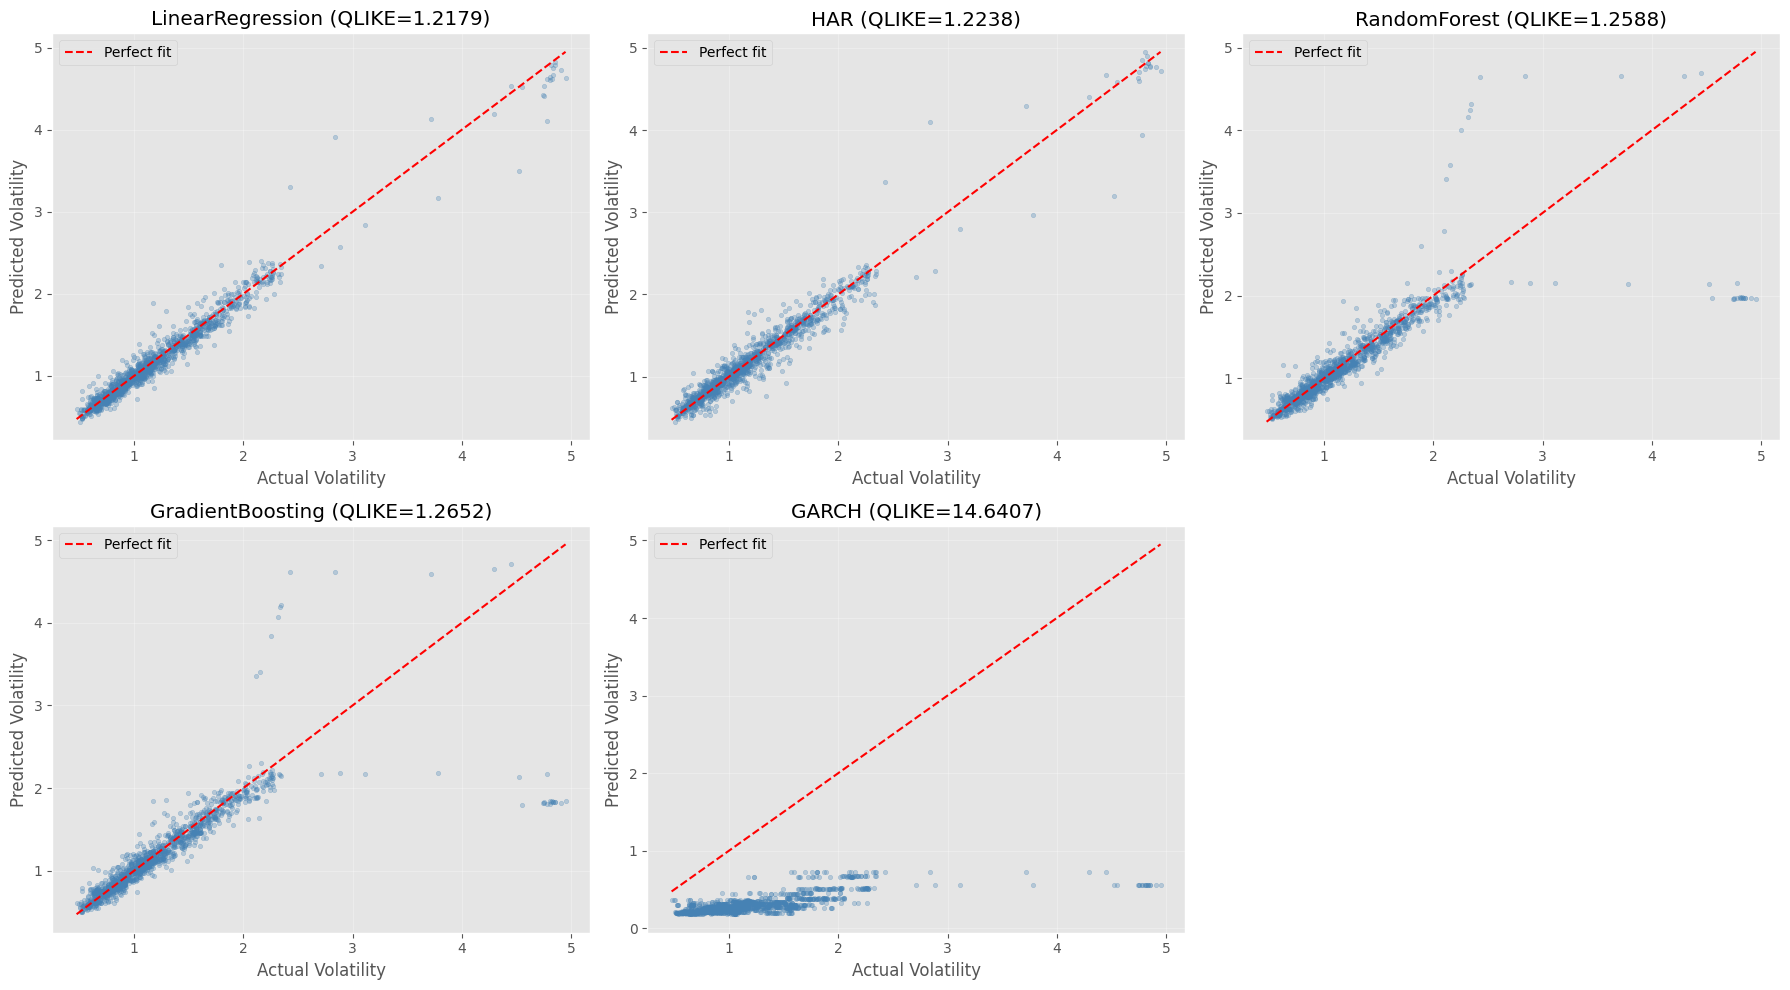

In [18]:
topModels = metricsTable.index[:5].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, modelName in enumerate(topModels):
    ax = axes[i]
    p = cleanPreds[modelName].values
    a = cleanPreds["Actual"].values

    mask = (p > 0.001) & (a > 0.001)
    p = p[mask]
    a = a[mask]

    ax.scatter(a, p, alpha=0.3, s=10, color="steelblue")
    ax.plot(
        [a.min(), a.max()],
        [a.min(), a.max()],
        "r--",
        lw=1.5,
        label="Perfect fit"
    )
    ax.set_xlabel("Actual Volatility")
    ax.set_ylabel("Predicted Volatility")
    ax.set_title(
        f'{modelName} (QLIKE={metricsTable.loc[modelName, "QLIKE"]:.4f})'
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")

plt.tight_layout()
plt.show()


### 4.3 Прогнозы на временной шкале

Сравнение прогнозов лучших моделей с фактической волатильностью на временном ряду (последние 252 дня тестового периода).


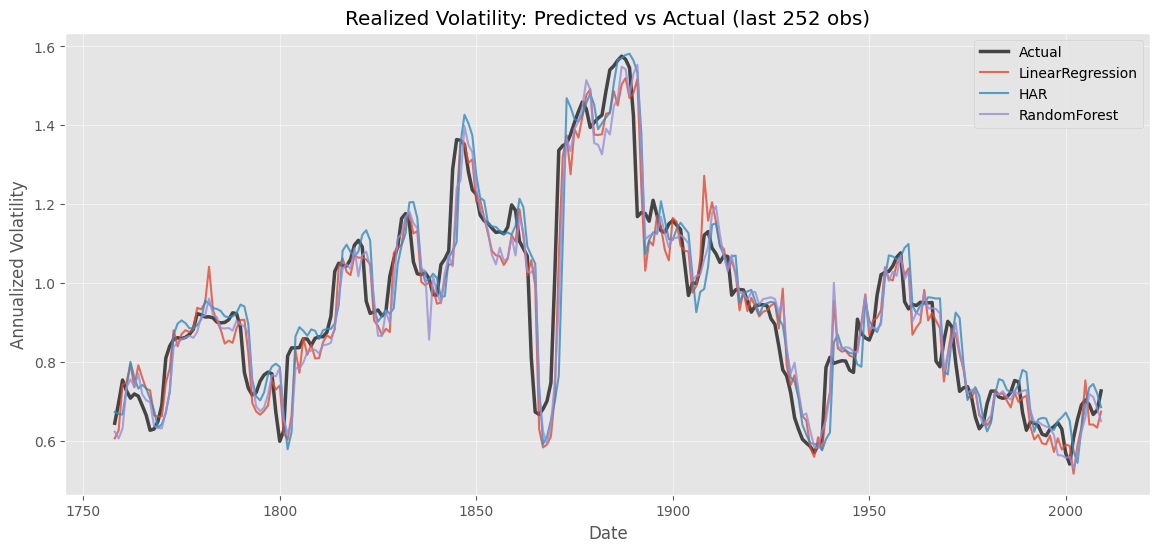

In [22]:
tsData = cleanPreds.tail(252)

plt.figure(figsize=(14, 6))
plt.plot(tsData.index, tsData['Actual'], label='Actual', color='black', lw=2.5, alpha=0.7)
for modelName in topModels[:3]:
    plt.plot(tsData.index, tsData[modelName], label=modelName, alpha=0.8, lw=1.5)

plt.title('Realized Volatility: Predicted vs Actual (last 252 obs)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


### 4.4 Сохранение результатов

In [25]:
outputPath = "resultsSummary.csv"
metricsTable.to_csv(outputPath)
print(f"Таблица метрик сохранена в '{outputPath}'")

fullOutputPath = "predictions.csv"
cleanPreds.to_csv(fullOutputPath)
print(f"Все прогнозы сохранены в '{fullOutputPath}'")
print(f"Файлы находятся в папке: {os.getcwd()}")


Таблица метрик сохранена в 'resultsSummary.csv'
Все прогнозы сохранены в 'predictions.csv'
Файлы находятся в папке: c:\Users\dgami\OneDrive\Документы\DataAnalysisProjects\RealizedVolatilityPrediction


## 5. Выводы

**Ключевые результаты:**

1. **Лучшей моделью по всем основным метрикам стала Linear Regression**:
   MAE = 0.0700, RMSE = 0.1071, QLIKE = 1.2179. Это означает, что в данном эксперименте простая линейная модель лучше всего приблизила будущую реализованную волатильность.

2. **HAR-модель показала второй результат**:
   MAE = 0.0760, RMSE = 0.1252, QLIKE = 1.2238. Ее качество оказалось близким к Linear Regression, что логично для задачи прогнозирования волатильности: волатильность обладает устойчивой автокорреляционной структурой, а HAR хорошо улавливает дневную, недельную и месячную компоненты.

3. **Random Forest и Gradient Boosting уступили линейным моделям**:
   Random Forest получил QLIKE = 1.2588, а Gradient Boosting — QLIKE = 1.2652. Вероятно, на выбранном наборе признаков и объеме данных сложные нелинейные модели хуже обобщают зависимость и могут переобучаться.

4. **GARCH показал худший результат**:
   MAE = 0.9032, RMSE = 1.0405, QLIKE = 14.6407. В текущей реализации GARCH заметно уступает моделям, которые напрямую используют realized volatility / bipower variation как target. Это может быть связано с особенностями спецификации, масштабированием доходностей или тем, что GARCH оценивает условную волатильность доходностей, а не напрямую BPV-volatility.

5. **Data leakage исключён**: признаки строятся только на основе исторических данных, а walk-forward validation имитирует реальный процесс прогнозирования, когда модель обучается на прошлом и прогнозирует следующий торговый день.

**Практический вывод:** в данном эксперименте простые линейные подходы оказались наиболее устойчивыми. Linear Regression дала лучший результат, а HAR подтвердила, что для прогнозирования реализованной волатильности сильную роль играют лаги и средние значения волатильности на разных горизонтах. Сложные ML-модели требуют более аккуратного подбора признаков и гиперпараметров, а GARCH в текущей постановке оказался слабым benchmark.